# Operating-space dataset for RQ1 (Plant A digital twin)

Calibrated coupled model (Plant A geometry and feed composition, `calibration_alpha_top_fixed`). Inputs and
ranges from `data/design/parameter_ranges.csv`; base case = calibrated Plant A state. Campaigns were run by
`rdt.operate` and stored in `data/lhs_runs/` (open-loop LHS N = 2000, closed-loop 15 x 15 S/C x load grid at the
measured outlet temperature 1105.55 K, Saltelli 4096 runs for Sobol indices); this notebook loads them and does the
screening and figures. **Life metrics use the Yeh (2021) Manaurite XM placeholder curve** and are reported as the
life-consumption rate 1/t_r relative to the Plant A base case.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from rdt import operate as op

pd.set_option("display.width", 250)
ranges = op.load_ranges(); print(ranges[["unit", "min", "max", "base_plant_A"]].to_string())
base = op.base_case(); b = op.base_run(base)
print("\nbase (calibrated Plant A):", {k: round(float(v), 4) for k, v in base.inputs().items()})
print(f"base outputs: T_out {b['T_out_K']:.1f} K, T_wo_max {b['T_wo_max_K']:.1f} K at z/L {b['z_frac_T_wo_max']:.2f}, dry H2 {b['dry_H2_pct']:.1f} %, CH4 slip {b['CH4_slip_dry_pct']:.2f} %, "
      f"efficiency {b['thermal_efficiency']:.3f}, sigma {b['sigma_hot_MPa']:.1f} MPa, log10 t_r {b['log10_t_r_hot']:.2f} (Yeh placeholder)")
meta = json.loads((op.LHS_DIR / "lhs_plantA_v1_meta.json").read_text())
lhs = pd.read_csv(op.LHS_DIR / "lhs_plantA_v1.csv.gz")
grid = pd.read_csv(op.LHS_DIR / "grid_sc_load_v1.csv.gz")
sob = json.loads((Path("..") / "data" / "design" / "sobol_v1.json").read_text())
print(f"\nLHS: {meta['n_converged']}/{meta['n_samples']} converged ({100*meta['convergence_rate']:.1f} %), {meta['wall_time_s']:.0f} s on {meta['n_jobs']} jobs, commit {meta['git_commit'][:8]}")
print(f"grid: {int((grid.converged == True).sum())}/{len(grid)} converged; Sobol: {sob['n_converged']}/{sob['n_runs']} converged in {sob['wall_time_s']:.0f} s")
print("\nLHS output ranges:"); print(lhs[["T_wo_max_K", "z_frac_T_wo_max", "T_out_K", "dry_H2_pct", "CH4_slip_dry_pct", "thermal_efficiency", "log10_t_r_hot", "life_consumption_ratio_to_base"]].describe().loc[["min", "50%", "max"]].round(3).to_string())


                       unit     min     max  base_plant_A
parameter                                                
steam_to_carbon           -    2.50    4.00          2.88
feed_per_tube_fraction    -    0.60    1.10          1.00
specific_firing_factor    -    0.85    1.15          1.00
inlet_T                   K  800.00  900.00        877.00
inlet_P                 bar   25.00   33.00         30.10
catalyst_activity         -    0.10    0.30          0.20
excess_air                %    5.00   20.00          9.20



base (calibrated Plant A): {'steam_to_carbon': 2.8922, 'feed_per_tube_fraction': 1.0, 'specific_firing_factor': 1.0, 'inlet_T': 884.55, 'inlet_P': 30.06, 'catalyst_activity': 0.2, 'excess_air': 21.6413}
base outputs: T_out 1109.2 K, T_wo_max 1146.7 K at z/L 0.43, dry H2 70.6 %, CH4 slip 7.81 %, efficiency 0.513, sigma 12.9 MPa, log10 t_r 7.90 (Yeh placeholder)

LHS: 2000/2000 converged (100.0 %), 67 s on -1 jobs, commit 311241cc
grid: 225/225 converged; Sobol: 4096/4096 converged in 139 s

LHS output ranges:
     T_wo_max_K  z_frac_T_wo_max   T_out_K  dry_H2_pct  CH4_slip_dry_pct  thermal_efficiency  log10_t_r_hot  life_consumption_ratio_to_base
min    1087.386            0.395  1042.455      68.082             2.445               0.480          5.899                           0.012
50%    1150.499            0.415  1109.265      71.813             6.386               0.562          7.879                           1.041
max    1219.473            1.000  1182.938      74.595           

In [2]:
targets = ["T_wo_max_K", "CH4_slip_dry_pct", "log10_t_r_hot"]
rows = []
for k in op.INPUT_NAMES:
    r = {"input": k}
    for y in targets:
        rho, p = spearmanr(lhs[k], lhs[y]); r[y] = rho; r[y + "_p"] = p
    rows.append(r)
spear = pd.DataFrame(rows).set_index("input")
print("Spearman rank correlations (open-loop LHS, N = %d):" % len(lhs)); print(spear[targets].round(3).to_string())
print("\nSobol indices (Saltelli N = 256, 4096 runs; mean ± 95 % CI):")
for y in ("T_wo_max_K", "log10_t_r_hot"):
    s = sob["outputs"][y]
    tab = pd.DataFrame({"S1": s["S1"], "S1_conf": s["S1_conf"], "ST": s["ST"], "ST_conf": s["ST_conf"]})
    print(f"\n{y}:"); print(tab.round(3).to_string())


Spearman rank correlations (open-loop LHS, N = 2000):
                        T_wo_max_K  CH4_slip_dry_pct  log10_t_r_hot
input                                                              
steam_to_carbon             -0.529            -0.202          0.485
feed_per_tube_fraction      -0.137             0.437          0.147
specific_firing_factor       0.628            -0.767         -0.573
inlet_T                      0.249            -0.298         -0.226
inlet_P                      0.112             0.145         -0.391
catalyst_activity           -0.253            -0.034          0.220
excess_air                  -0.326             0.233          0.304

Sobol indices (Saltelli N = 256, 4096 runs; mean ± 95 % CI):

T_wo_max_K:
                           S1  S1_conf     ST  ST_conf
steam_to_carbon         0.314    0.092  0.308    0.056
feed_per_tube_fraction  0.025    0.027  0.025    0.005
specific_firing_factor  0.385    0.105  0.395    0.073
inlet_T                 0.062    0.047 

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig07_operating_maps.png


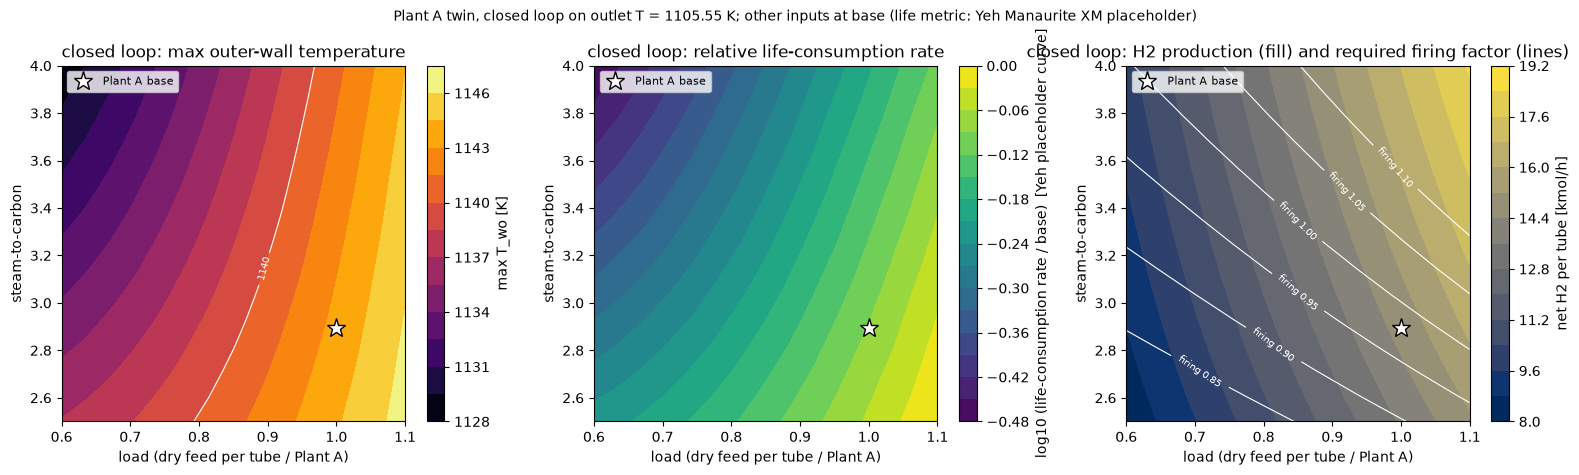

grid point nearest base: S/C 2.929 load 0.993 -> firing 0.982, T_wo_max 1143.2, ratio 0.803
map extremes: T_wo_max 1129-1147 K; ratio 0.34-1.00; firing 0.791-1.233; H2 8.2-18.5 kmol/h
  load 0.60: along S/C 2.5->4.0  T_wo_max 1137->1129 K, ratio 0.59->0.34, firing 0.791->0.996, H2 8.19->10.13
  load 0.99: along S/C 2.5->4.0  T_wo_max 1144->1141 K, ratio 0.87->0.65, firing 0.895->1.171, H2 13.58->16.70
  load 1.10: along S/C 2.5->4.0  T_wo_max 1147->1144 K, ratio 1.00->0.77, firing 0.932->1.233, H2 15.06->18.48


In [3]:
# fig07: closed-loop maps over S/C x load at T_out = 1105.55 K
g = grid[grid.converged == True].copy()
sc = np.sort(g.steam_to_carbon.unique()); ld = np.sort(g.feed_per_tube_fraction.unique())
def pivot(col): return g.pivot(index="steam_to_carbon", columns="feed_per_tube_fraction", values=col).reindex(index=sc, columns=ld).to_numpy()
Z_T = pivot("T_wo_max_K"); Z_L = pivot("life_consumption_ratio_to_base"); Z_F = pivot("specific_firing_factor"); Z_H = pivot("H2_net_kmol_h")
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
LD, SC = np.meshgrid(ld, sc)
c0 = ax[0].contourf(LD, SC, Z_T, levels=16, cmap="inferno"); fig.colorbar(c0, ax=ax[0], label="max T_wo [K]")
cs = ax[0].contour(LD, SC, Z_T, levels=[1120, 1140, 1160, 1180], colors="w", linewidths=0.8); ax[0].clabel(cs, fmt="%.0f", fontsize=7)
ax[0].set_title("closed loop: max outer-wall temperature")
c1 = ax[1].contourf(LD, SC, np.log10(Z_L), levels=16, cmap="viridis"); cb = fig.colorbar(c1, ax=ax[1], label="log10 (life-consumption rate / base)  [Yeh placeholder curve]")
cs = ax[1].contour(LD, SC, np.log10(Z_L), levels=[-1, -0.5, 0, 0.5, 1], colors="w", linewidths=0.8); ax[1].clabel(cs, fmt="%.1f", fontsize=7)
ax[1].set_title("closed loop: relative life-consumption rate")
c2 = ax[2].contourf(LD, SC, Z_H, levels=16, cmap="cividis"); fig.colorbar(c2, ax=ax[2], label="net H2 per tube [kmol/h]")
cs = ax[2].contour(LD, SC, Z_F, levels=[0.85, 0.9, 0.95, 1.0, 1.05, 1.1], colors="w", linewidths=0.8); ax[2].clabel(cs, fmt="firing %.2f", fontsize=7)
ax[2].set_title("closed loop: H2 production (fill) and required firing factor (lines)")
for a in ax:
    a.plot([1.0], [base.steam_to_carbon], "w*", ms=14, mec="k", label="Plant A base"); a.set_xlabel("load (dry feed per tube / Plant A)"); a.set_ylabel("steam-to-carbon"); a.legend(loc="upper left", fontsize=8)
fig.suptitle("Plant A twin, closed loop on outlet T = 1105.55 K; other inputs at base (life metric: Yeh Manaurite XM placeholder)", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig07_operating_maps.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()
gb = g.iloc[(np.abs(g.steam_to_carbon - base.steam_to_carbon) + np.abs(g.feed_per_tube_fraction - 1.0)).argmin()]
print("grid point nearest base: S/C %.3f load %.3f -> firing %.3f, T_wo_max %.1f, ratio %.3f" % (gb.steam_to_carbon, gb.feed_per_tube_fraction, gb.specific_firing_factor, gb.T_wo_max_K, gb.life_consumption_ratio_to_base))
print("map extremes: T_wo_max %.0f-%.0f K; ratio %.2f-%.2f; firing %.3f-%.3f; H2 %.1f-%.1f kmol/h" % (np.nanmin(Z_T), np.nanmax(Z_T), np.nanmin(Z_L), np.nanmax(Z_L), np.nanmin(Z_F), np.nanmax(Z_F), np.nanmin(Z_H), np.nanmax(Z_H)))
for l_ in (0.6, 1.0, 1.1):
    j = np.argmin(np.abs(ld - l_)); print(f"  load {ld[j]:.2f}: along S/C 2.5->4.0  T_wo_max {Z_T[0,j]:.0f}->{Z_T[-1,j]:.0f} K, ratio {Z_L[0,j]:.2f}->{Z_L[-1,j]:.2f}, firing {Z_F[0,j]:.3f}->{Z_F[-1,j]:.3f}, H2 {Z_H[0,j]:.2f}->{Z_H[-1,j]:.2f}")


saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig08_sobol.png


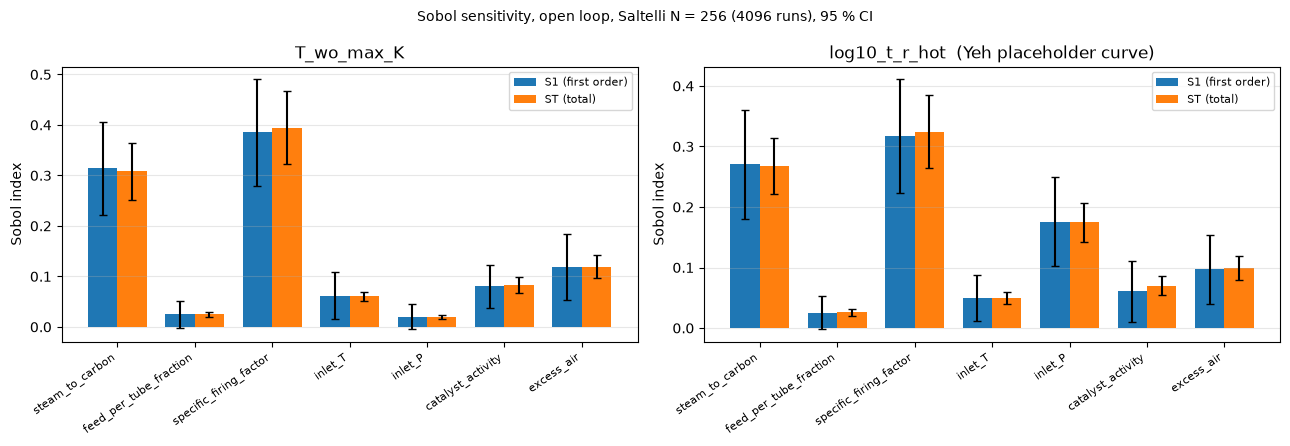

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
names = list(op.INPUT_NAMES); x = np.arange(len(names)); w = 0.38
for a, y in zip(ax, ("T_wo_max_K", "log10_t_r_hot")):
    s = sob["outputs"][y]
    a.bar(x - w/2, [s["S1"][k] for k in names], w, yerr=[s["S1_conf"][k] for k in names], capsize=3, label="S1 (first order)")
    a.bar(x + w/2, [s["ST"][k] for k in names], w, yerr=[s["ST_conf"][k] for k in names], capsize=3, label="ST (total)")
    a.set_xticks(x); a.set_xticklabels(names, rotation=35, ha="right", fontsize=8); a.set_ylabel("Sobol index"); a.set_title(y + ("  (Yeh placeholder curve)" if "t_r" in y else "")); a.grid(alpha=0.3, axis="y"); a.legend(fontsize=8)
fig.suptitle("Sobol sensitivity, open loop, Saltelli N = 256 (4096 runs), 95 % CI", fontsize=10)
fig.tight_layout(); out = Path("..") / "paper" / "figures" / "fig08_sobol.png"; fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()
